# Bayesian Optimal Experimental Design — Burgers Equation Tutorial

This notebook demonstrates our BOED proposal on the 1D viscous Burgers equation.
The pipeline covers:
1. **Setup** — PDE model, noise, and discretisation
2. **Prior** — GP prior split into parameter of interest $\theta$ and nuisance $\eta$
3. **Forward model** — $G:(\theta,\eta)\mapsto u(\cdot,T)$
4. **Finite-difference Jacobians** — $J_\theta$, $J_\eta$, and their Monte-Carlo expectations
5. **Covariance matrices** — $\Sigma_Y$, $\Sigma_{\rm noise}$, $\Sigma_{\rm signal}$, $\Sigma_{Y|\theta}$
6. **EIG estimators** — upper bound (BS) and direct estimator (BI)
7. **Greedy sensor placement** comparison

## 1. Imports

In [174]:
import numpy as np
import numpy.linalg as la
import scipy.linalg as sla
import matplotlib.pyplot as plt

from boed.priors.kernels import Matern32, Matern12
from boed.priors.gp_priors import GaussianProcessPrior
from boed.core.noise import NoiseModel, ColoredNoise
from boed.core import make_u0
from boed.pde.burgers import Burgers_CN
from boed.utils.observation import build_selection_matrices
from joblib import Parallel, delayed
import warnings

## 2. Setup

We define the spatial grid, PDE model, true initial condition, and observation noise.

In [175]:
np.random.seed(42)

N        = 200      # number of interior grid points
dt       = 0.001
n_steps  = 100
sigma    = 0.1    # noise standard deviation
lambda_  = 1.
n_samples = 600

x_grid = np.linspace(0, 1, N + 2)[1:-1]


model   = Burgers_CN(N=N, dt=dt, diffusivity=0.02, lambda_=lambda_)
u0_true = make_u0(x_grid, "gaussian", center=0.25, width=0.07, amplitude=1.5)
noise   = NoiseModel(sigma_noise=sigma)

## 3. Prior

The joint parameter $(\theta, \eta) \in \mathbb{R}^{d+q}$ follows a Gaussian prior:

$$
(\theta, \eta) \sim \mathcal{N}\!\left(m_{(\theta,\eta)},\;
\Sigma_{(\theta,\eta)}\right),
\qquad
\Sigma_{(\theta,\eta)} =
\begin{pmatrix}
\Sigma_\theta & \Sigma_{\theta\eta} \\
\Sigma_{\eta\theta} & \Sigma_\eta
\end{pmatrix}
$$

where $\theta$ is the parameter of interest and $\eta$ is the nuisance parameter.
Both are drawn from the same GP prior, split at the midpoint of the grid.

In [176]:
kernel = Matern32(length_scale=0.2, sigma=1.0)
prior  = GaussianProcessPrior(kernel, mu=np.zeros(N), nx=N)

eigvals = np.linalg.eigvalsh(prior.Sigma)
lambda_max = eigvals[-1]
lambda_min = eigvals[0]
# print(f"lambda_max: {lambda_max:.2e}, lambda_min: {lambda_min:.2e}")
# jitter ~ lambda_max / 1000
jitter = lambda_max / 1000
# print(f"jitter suggéré: {jitter:.2e}")

prior.Sigma += jitter

d = q = N // 2

# Marginal dicts (kept for backward-compat with downstream code)
theta_prior = {"mu": prior.mu[:d],  "Sigma": prior.Sigma[:d, :d]}
eta_prior   = {"mu": prior.mu[d:],  "Sigma": prior.Sigma[d:, d:]}

Sigma_theta_eta = prior.Sigma[:d, d:]
Sigma_eta_theta = prior.Sigma[d:, :d]

# ── Joint prior z = (theta, eta) ~ N(m_joint, Sigma_joint) ───────────────────
# All Monte-Carlo estimators must draw from this joint distribution so that
# the cross-covariance Sigma_theta_eta is respected.
joint_prior = {
    "mu":    prior.mu,      # shape (N,)
    "Sigma": prior.Sigma,   # shape (N, N)
    "d":     d,             # dim of theta block
    "q":     q,             # dim of eta   block
}

# print(np.linalg.cond(prior.Sigma))


In [177]:
def sample_joint_prior(joint_prior, n_samples, rng=None):
    """Draw n_samples from the joint prior z = (theta, eta) ~ N(m, Sigma).

    Parameters
    ----------
    joint_prior : dict with keys 'mu' (N,), 'Sigma' (N,N), 'd', 'q'
    n_samples   : int
    rng         : np.random.Generator or None

    Returns
    -------
    theta_samples : ndarray (n_samples, d)
    eta_samples   : ndarray (n_samples, q)
    """
    if rng is None:
        rng = np.random.default_rng()
    d = joint_prior["d"]
    z = rng.multivariate_normal(
        mean=joint_prior["mu"],
        cov=joint_prior["Sigma"],
        size=n_samples,
    )
    return z[:, :d], z[:, d:]


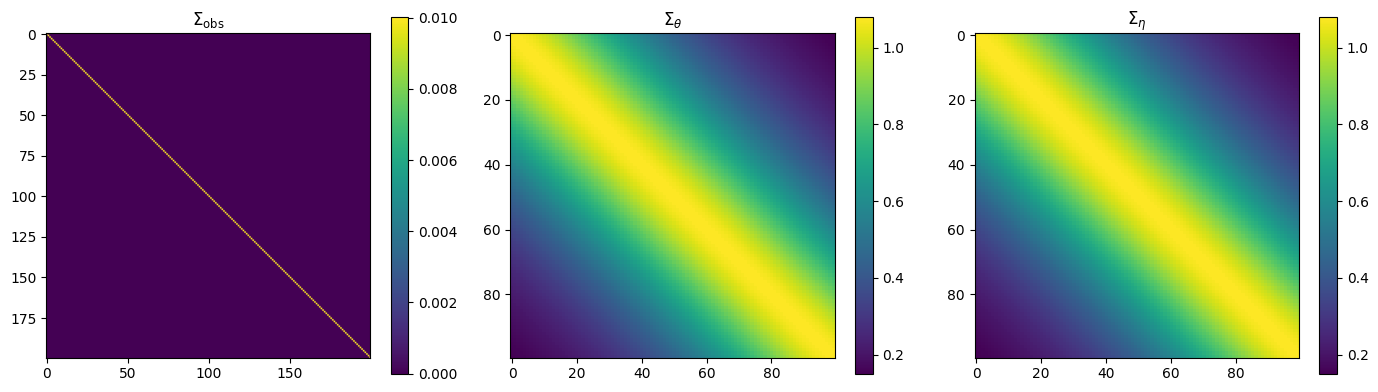

In [178]:
def plot_matrices(matrices, titles, figsize=None, cmap="viridis"):
    """Display a row of matrices side by side with individual colour-bars.

    Parameters
    ----------
    matrices : list of ndarray
        Square matrices to display.
    titles : list of str
        LaTeX-compatible title for each matrix.
    figsize : tuple, optional
        Figure size; defaults to (5 * n, 4).
    cmap : str, optional
        Matplotlib colour-map name.
    """
    n = len(matrices)
    if figsize is None:
        figsize = (5 * n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap=cmap)
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


plot_matrices(
    [noise.get_covariance(N), theta_prior["Sigma"], eta_prior["Sigma"]],
    [r"$\Sigma_{\rm obs}$", r"$\Sigma_\theta$", r"$\Sigma_\eta$"],
    figsize=(14, 4),
)

## 4. Forward Model

The forward operator $G:(\theta,\eta)\mapsto u(\cdot,T)\in\mathbb{R}^N$ runs the
Burgers PDE from the concatenated initial condition $(\theta,\eta)$.
When `eta` is `None`, $\theta$ is used as the full initial condition.

In [179]:
def make_forward_model(pde_model, n_steps):
    """Return the forward operator G(theta, eta) -> u(·, T).

    Parameters
    ----------
    pde_model : object
        PDE solver with an ``evolve(u0, n_steps)`` method.
    n_steps : int
        Number of time steps to run.

    Returns
    -------
    G : callable
        Function ``G(theta, eta) -> ndarray`` of shape ``(N,)``.
    """
    def G(theta: np.ndarray, eta: np.ndarray | None):
        u0 = np.concatenate((theta, eta), axis=None) if eta is not None else theta
        return pde_model.evolve(u0=u0, n_steps=n_steps)[-1, :]
    return G


theta, eta = np.split(u0_true, 2)
print(f"theta size : {theta.size}")
print(f"eta   size : {eta.size}")

G = make_forward_model(pde_model=model, n_steps=n_steps)

# Sanity check: both calling conventions must produce the same output
u1 = G(theta=theta, eta=eta)
u2 = G(theta=u0_true.copy(), eta=None)
print(f"Consistency check ||G(theta,eta) - G(u0)|| = {np.linalg.norm(u1 - u2):.2e}")

theta size : 100
eta   size : 100
Consistency check ||G(theta,eta) - G(u0)|| = 0.00e+00


## 5. Finite-Difference Jacobians

### 5a. Jacobian with respect to $\theta$

$$
J_\theta(\theta,\eta) \in \mathbb{R}^{N\times d},\qquad
[J_\theta]_{\cdot,j} \approx \frac{G(\theta+h e_j,\eta)-G(\theta-h e_j,\eta)}{2h}
$$

Cost: $2d$ forward evaluations per sample.

In [180]:
def jacobian_fd_theta(G, theta, eta, h=None):
    """Central finite-difference Jacobian of G with respect to theta.

    Parameters
    ----------
    G     : callable  R^d x R^q -> R^m
    theta : ndarray, shape (d,)
    eta   : ndarray, shape (q,)
    h     : float, optional
        Step size.  Defaults to ``eps^{1/3} * (||theta|| + 1e-8)``.

    Returns
    -------
    J_theta : ndarray, shape (m, d)
    """
    d = theta.shape[0]
    if h is None:
        h = np.finfo(float).eps ** (1 / 3) * (la.norm(theta) + 1e-8)

    m = G(theta, eta).shape[0]
    J = np.zeros((m, d))
    for j in range(d):
        e_j = np.zeros(d)
        e_j[j] = 1.0
        J[:, j] = (G(theta + h * e_j, eta) - G(theta - h * e_j, eta)) / (2 * h)
    return J

### 5b. Jacobian with respect to $\eta$

$$
J_\eta(\theta,\eta) \in \mathbb{R}^{N\times q},\qquad
[J_\eta]_{\cdot,j} \approx \frac{G(\theta,\eta+h e_j)-G(\theta,\eta-h e_j)}{2h}
$$

Cost: $2q$ forward evaluations per sample.

In [181]:
def jacobian_fd_eta(G, theta, eta, h=None):
    """Central finite-difference Jacobian of G with respect to eta.

    Parameters
    ----------
    G     : callable  R^d x R^q -> R^m
    theta : ndarray, shape (d,)
    eta   : ndarray, shape (q,)
    h     : float, optional
        Step size.  Defaults to ``eps^{1/3} * (||eta|| + 1e-8)``.

    Returns
    -------
    J_eta : ndarray, shape (m, q)
    """
    q = eta.shape[0]
    if h is None:
        h = np.finfo(float).eps ** (1 / 3) * (la.norm(eta) + 1e-8)

    m = G(theta, eta).shape[0]
    J = np.zeros((m, q))
    for j in range(q):
        e_j = np.zeros(q)
        e_j[j] = 1.0
        J[:, j] = (G(theta, eta + h * e_j) - G(theta, eta - h * e_j)) / (2 * h)
    return J

### 5c. Full Jacobian

The full Jacobian $J_{(\theta,\eta)}$ is the horizontal concatenation $[J_\theta \mid J_\eta]$.

In [182]:
def jacobian_fd_full(G, theta, eta, h_theta=None, h_eta=None):
    """Full Jacobian [J_theta | J_eta], shape (m, d+q)."""
    J_theta = jacobian_fd_theta(G, theta, eta, h=h_theta)
    J_eta   = jacobian_fd_eta(G, theta, eta, h=h_eta)
    return np.concatenate((J_theta, J_eta), axis=1)


In [183]:
hs = [1e-2, 1e-4, 1e-6, 1e-8]

J_theta_list = []
J_eta_list   = []
J_full_list  = []

for h in hs:
    J_theta  = jacobian_fd_theta(G, theta=theta, eta=eta, h=h)
    J_eta    = jacobian_fd_eta(G,   theta=theta, eta=eta, h=h)
    J_full   = jacobian_fd_full(G,  theta=theta, eta=eta, h_theta=h, h_eta=h)

    J_theta_list.append(J_theta)
    J_eta_list.append(J_eta)
    J_full_list.append(J_full)

    print(f"h = {h}")
    print(f"  J_theta shape : {J_theta.shape}")
    print(f"  J_eta   shape : {J_eta.shape}")
    print(f"  J_full  shape : {J_full.shape}")

h = 0.01
  J_theta shape : (200, 100)
  J_eta   shape : (200, 100)
  J_full  shape : (200, 200)
h = 0.0001
  J_theta shape : (200, 100)
  J_eta   shape : (200, 100)
  J_full  shape : (200, 200)
h = 1e-06
  J_theta shape : (200, 100)
  J_eta   shape : (200, 100)
  J_full  shape : (200, 200)
h = 1e-08
  J_theta shape : (200, 100)
  J_eta   shape : (200, 100)
  J_full  shape : (200, 200)


In [184]:
print("\nRelative differences (theta):")
for i in range(len(hs)-1):
    J1 = J_theta_list[i]
    J2 = J_theta_list[i+1]
    rel_diff = np.linalg.norm(J1 - J2) / np.linalg.norm(J2)
    print(f"h={hs[i]} -> {hs[i+1]} : {rel_diff:.2e}")

print("\nRelative differences (eta):")
for i in range(len(hs)-1):
    J1 = J_eta_list[i]
    J2 = J_eta_list[i+1]
    rel_diff = np.linalg.norm(J1 - J2) / np.linalg.norm(J2)
    print(f"h={hs[i]} -> {hs[i+1]} : {rel_diff:.2e}")

print("\nRelative differences (full):")
for i in range(len(hs)-1):
    J1 = J_full_list[i]
    J2 = J_full_list[i+1]
    rel_diff = np.linalg.norm(J1 - J2) / np.linalg.norm(J2)
    print(f"h={hs[i]} -> {hs[i+1]} : {rel_diff:.2e}")


Relative differences (theta):
h=0.01 -> 0.0001 : 8.97e-08
h=0.0001 -> 1e-06 : 8.49e-09
h=1e-06 -> 1e-08 : 8.40e-07

Relative differences (eta):
h=0.01 -> 0.0001 : 8.57e-08
h=0.0001 -> 1e-06 : 5.15e-09
h=1e-06 -> 1e-08 : 4.27e-07

Relative differences (full):
h=0.01 -> 0.0001 : 8.78e-08
h=0.0001 -> 1e-06 : 7.13e-09
h=1e-06 -> 1e-08 : 6.79e-07


## 6. Monte-Carlo Estimation of $l_\theta$, $l_\eta$, and $l_{(\theta,\eta)}$

$$
l_\theta(u) = \mathbb{E}[J_\theta(\theta,\eta)^\top] \in \mathbb{R}^{d\times N}
$$
$$
l_\eta(u) = \mathbb{E}[J_\eta(\theta,\eta)^\top] \in \mathbb{R}^{q\times N}
$$
$$
l_{(\theta,\eta)}(u) = \mathbb{E}[J_{(\theta,\eta)}(\theta,\eta)^\top] \in \mathbb{R}^{(d+q)\times N}
$$

Samples are drawn from the **prior** $\pi_0(\theta,\eta)$ (pre-experimental setting,
no observations yet available).

In [185]:
def _one_sample(G, theta, eta):
    J_theta_T = jacobian_fd_theta(G, theta, eta).T
    J_eta_T   = jacobian_fd_eta(G, theta, eta).T
    return J_theta_T, J_eta_T


def estimate_E_JT(G, joint_prior, n_samples, rng=None):

    theta_samples, eta_samples = sample_joint_prior(
        joint_prior, n_samples, rng=rng
    )

    results = Parallel(n_jobs=-1)(
        delayed(_one_sample)(G, theta_samples[k], eta_samples[k])
        for k in range(n_samples)
    )

    J_theta_T_0, J_eta_T_0 = results[0]
    EJ_theta_T_sum = np.zeros_like(J_theta_T_0, dtype=float)
    EJ_eta_T_sum   = np.zeros_like(J_eta_T_0, dtype=float)

    for Jt, Je in results:
        EJ_theta_T_sum += Jt
        EJ_eta_T_sum   += Je

    EJ_theta_T = EJ_theta_T_sum / n_samples
    EJ_eta_T   = EJ_eta_T_sum / n_samples
    EJ_full_T  = np.concatenate((EJ_theta_T, EJ_eta_T), axis=0)

    return {
        "EJ_theta_T": EJ_theta_T,
        "EJ_eta_T": EJ_eta_T,
        "EJ_full_T": EJ_full_T
    }

l_theta shape : (100, 200)
l_eta   shape : (100, 200)
l_full  shape : (200, 200)


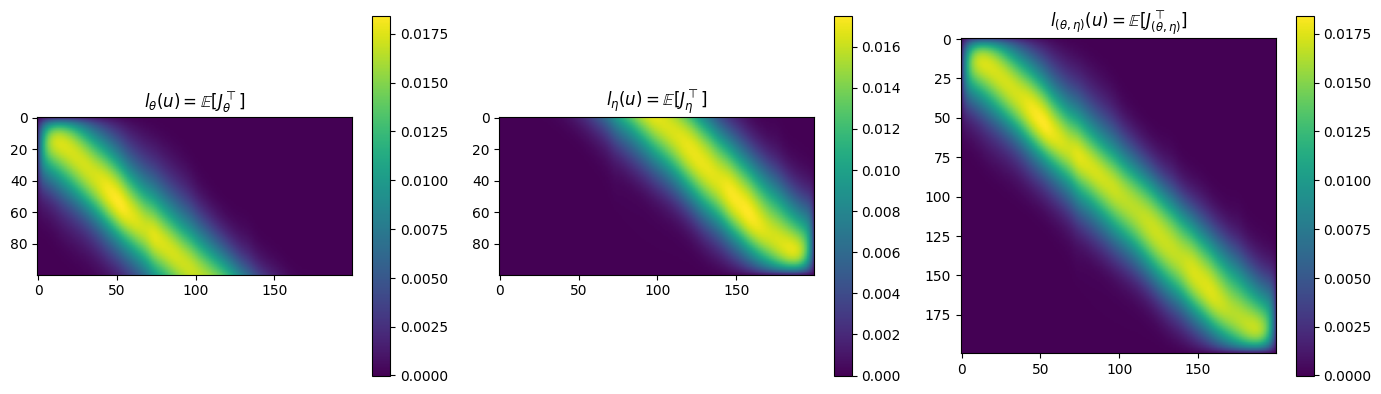

In [186]:
res_l = estimate_E_JT(G=G, joint_prior=joint_prior, n_samples=n_samples)

print(f"l_theta shape : {res_l['EJ_theta_T'].shape}")
print(f"l_eta   shape : {res_l['EJ_eta_T'].shape}")
print(f"l_full  shape : {res_l['EJ_full_T'].shape}")

plot_matrices(
    [res_l["EJ_theta_T"], res_l["EJ_eta_T"], res_l["EJ_full_T"]],
    [
        r"$l_\theta(u) = \mathbb{E}[J_\theta^\top]$",
        r"$l_\eta(u)   = \mathbb{E}[J_\eta^\top]$",
        r"$l_{(\theta,\eta)}(u) = \mathbb{E}[J_{(\theta,\eta)}^\top]$",
    ],
    figsize=(14, 4),
)

## 7. Monte-Carlo Estimation of $\mathcal{H}_\theta^{\Sigma_{\rm obs}}$, $\mathcal{H}_\eta^{\Sigma_{\rm obs}}$

$$
\mathcal{H}_\theta^{\Sigma_{\rm obs}}(u)
= \mathrm{Cov}\bigl(J_\theta(\theta,\eta)^\top \Sigma_{\rm obs}^{-1/2}\bigr)
$$

$$
\mathcal{H}_\eta^{\Sigma_{\rm obs}}(u)
= \mathrm{Cov}\bigl(J_\eta(\theta,\eta)^\top \Sigma_{\rm obs}^{-1/2}\bigr)
$$

$$
\mathcal{H}_{(\theta,\eta)}^{\Sigma_{\rm obs}}(u)
= \mathrm{Cov}\left(\begin{pmatrix}
J_\theta(\theta,\eta)^\top\\
J_\eta(\theta,\eta)^\top
\end{pmatrix} \Sigma_{\rm obs}^{-1/2}\right)
$$

Samples are drawn from the prior $\pi_0(\theta,\eta)$.

In [187]:
# Les fonctions jacobian_fd_theta, jacobian_fd_eta et sample_joint_prior
# doivent être définies ailleurs ou importées.

def _compute_z(theta, eta, G, h_theta, h_eta, Sigma_inv_sqrt):
    """Calcule Z_theta et Z_eta pour un seul échantillon (theta, eta)."""
    J_theta = jacobian_fd_theta(G, theta, eta, h=h_theta)
    J_eta   = jacobian_fd_eta(G, theta, eta, h=h_eta)
    Z_theta = J_theta.T @ Sigma_inv_sqrt
    Z_eta   = J_eta.T   @ Sigma_inv_sqrt
    return Z_theta, Z_eta

def estimate_jacobian_covariances_mc(
    G, joint_prior, Sigma_obs, n_samples,
    h_theta=None, h_eta=None, unbiased=False, rng=None,
    n_jobs=-1,  # nouveau paramètre : nombre de workers joblib
):
    """Monte-Carlo estimation of Cov(Z_theta), Cov(Z_eta), and Cov_full, where:

        Z_theta = J_theta(theta, eta)^T @ Sigma_obs^{-1/2}   shape (d, m)
        Z_eta   = J_eta(theta, eta)^T   @ Sigma_obs^{-1/2}   shape (q, m)

    Samples (theta, eta) from the joint prior so that Sigma_theta_eta is
    respected.

    Parameters
    ----------
    G           : callable  G(theta, eta) -> R^m
    joint_prior : dict with keys 'mu' (N,), 'Sigma' (N,N), 'd', 'q'
    Sigma_obs   : ndarray (m, m)  — symmetric positive definite
    n_samples   : int
    h_theta, h_eta : float or None  — finite-difference step sizes
    unbiased    : bool  — use 1/(n-1) instead of 1/n
    rng         : np.random.Generator or None
    n_jobs      : int  — number of parallel jobs for joblib (-1 = all CPUs)

    Returns
    -------
    dict with Cov_theta, Cov_eta, Cov_theta_eta, Cov_full
    """
    Sigma_obs = np.asarray(Sigma_obs, dtype=float)

    # Symmetric square-root inverse of Sigma_obs via eigendecomposition
    evals, evecs = la.eigh(Sigma_obs)
    if np.any(evals <= 0):
        raise ValueError("Sigma_obs must be symmetric positive definite.")
    Sigma_inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T

    # Génération des échantillons (pas parallélisée)
    theta_samples, eta_samples = sample_joint_prior(joint_prior, n_samples, rng=rng)

    # Parallélisation des calculs de Z_theta et Z_eta
    results = Parallel(n_jobs=n_jobs)(
        delayed(_compute_z)(theta_samples[k], eta_samples[k],
                            G, h_theta, h_eta, Sigma_inv_sqrt)
        for k in range(n_samples)
    )

    # Séparation des résultats en deux listes
    Z_theta_list, Z_eta_list = zip(*results)
    Z_theta_arr = np.asarray(Z_theta_list, dtype=float)  # (n, d, m)
    Z_eta_arr   = np.asarray(Z_eta_list,   dtype=float)  # (n, q, m)

    # Calcul des moyennes
    Z_theta_mean = np.mean(Z_theta_arr, axis=0)
    Z_eta_mean   = np.mean(Z_eta_arr,   axis=0)

    d_theta = Z_theta_mean.shape[0]
    d_eta   = Z_eta_mean.shape[0]

    Cov_theta     = np.zeros((d_theta, d_theta))
    Cov_eta       = np.zeros((d_eta,   d_eta))
    Cov_theta_eta = np.zeros((d_theta, d_eta))

    for k in range(n_samples):
        Dt = Z_theta_arr[k] - Z_theta_mean
        De = Z_eta_arr[k]   - Z_eta_mean
        Cov_theta     += Dt @ Dt.T
        Cov_eta       += De @ De.T
        Cov_theta_eta += Dt @ De.T

    denom = (n_samples - 1) if (unbiased and n_samples > 1) else n_samples
    Cov_theta     /= denom
    Cov_eta       /= denom
    Cov_theta_eta /= denom

    # Symmetrise to absorb floating-point asymmetry
    Cov_theta = 0.5 * (Cov_theta + Cov_theta.T)
    Cov_eta   = 0.5 * (Cov_eta   + Cov_eta.T)

    Cov_full = np.block([
        [Cov_theta,       Cov_theta_eta],
        [Cov_theta_eta.T, Cov_eta],
    ])

    return {
        "Cov_theta":     Cov_theta,
        "Cov_eta":       Cov_eta,
        "Cov_theta_eta": Cov_theta_eta,
        "Cov_full":      Cov_full,
    }

H_theta shape      : (100, 100)
H_eta   shape      : (100, 100)
H_theta_eta shape  : (100, 100)


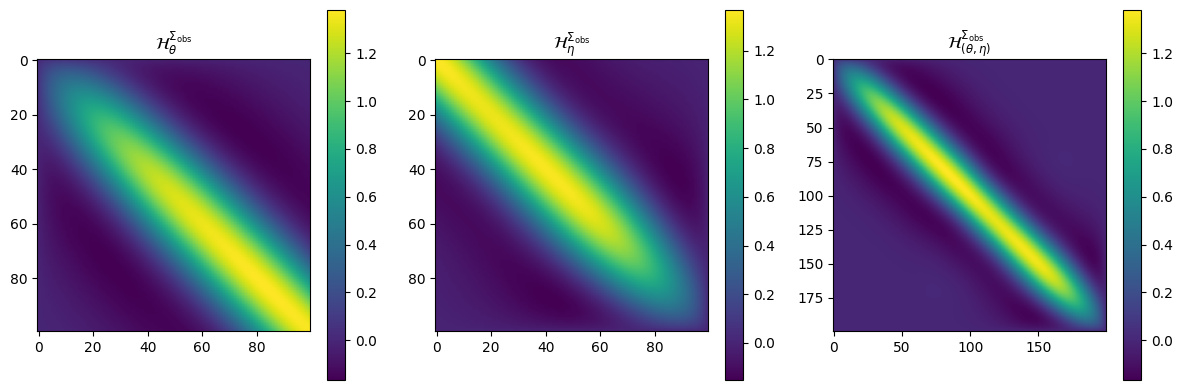

In [188]:
res_H = estimate_jacobian_covariances_mc(
    G=G, joint_prior=joint_prior,
    Sigma_obs=noise.get_covariance(N), n_samples=n_samples,
)

print(f"H_theta shape      : {res_H['Cov_theta'].shape}")
print(f"H_eta   shape      : {res_H['Cov_eta'].shape}")
print(f"H_theta_eta shape  : {res_H['Cov_theta_eta'].shape}")

plot_matrices(
    [res_H["Cov_theta"], res_H["Cov_eta"], res_H["Cov_full"]],
    [
        r"$\mathcal{H}_\theta^{\Sigma_{\rm obs}}$",
        r"$\mathcal{H}_\eta^{\Sigma_{\rm obs}}$",
        r"$\mathcal{H}_{(\theta,\eta)}^{\Sigma_{\rm obs}}$",
    ],
    figsize=(12, 4),
)

## 8. Covariance Matrices

### 8a. Marginal output covariance $\Sigma_Y$

$$
\Sigma_Y = \Sigma_{\rm obs} + \mathrm{Cov}_{\pi_0}[G(\theta,\eta)]
$$

In [189]:
def estimate_Sigma_Y(G, joint_prior, Sigma_obs, n_samples, rng=None):
    """Estimate Sigma_Y = Sigma_obs + Cov_{pi_0}[G(theta, eta)] by Monte Carlo.

    Samples from the joint prior.

    Parameters
    ----------
    G           : callable
    joint_prior : dict with keys 'mu', 'Sigma', 'd', 'q'
    Sigma_obs   : ndarray (m, m)
    n_samples   : int
    rng         : np.random.Generator or None

    Returns
    -------
    Sigma_Y : ndarray (m, m)
    """
    theta_samples, eta_samples = sample_joint_prior(joint_prior, n_samples, rng=rng)
    U = Parallel(n_jobs=-1)(
            delayed(G)(theta_samples[k], eta_samples[k]) for k in range(n_samples))
    U = np.array(U)
    SY = Sigma_obs + np.cov(U, rowvar=False, bias=False)
    return 0.5 * (SY + SY.T)  # symmetrise


In [190]:
Sigma_Y = estimate_Sigma_Y(
    G=G, joint_prior=joint_prior,
    Sigma_obs=noise.get_covariance(N), n_samples=n_samples,
)


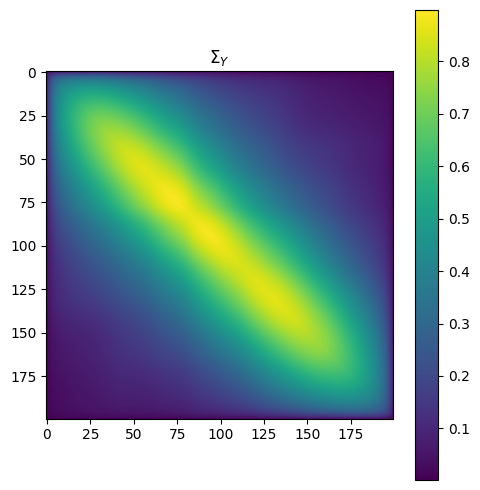

In [191]:

plot_matrices([Sigma_Y], [r"$\Sigma_Y$"], figsize=(5, 5))

### 8b. Noise covariance $\Sigma_{\rm noise}$

$$
\Sigma_{\rm noise} = \Sigma_{\rm obs}
+ l_\eta(u)^\top
  \left(\Sigma_{\eta|\theta}^{-1} + \mathcal{H}_\eta^{\Sigma_{\rm obs}}\right)^{-1}
  l_\eta(u)
$$

In [192]:
def compute_Sigma_noise(L_eta, H_eta, Sigma_eta_given_theta, Sigma_obs):
    """Compute the noise covariance matrix.

    Parameters
    ----------
    L_eta                 : ndarray (q, m)  — l_eta(u)
    H_eta                 : ndarray (q, q)  — H_eta^{Sigma_obs}
    Sigma_eta_given_theta : ndarray (q, q)  — Cov(eta | theta)
    Sigma_obs             : ndarray (m, m)

    Returns
    -------
    Sigma_noise : ndarray (m, m)
    """
    q = Sigma_eta_given_theta.shape[0]
    HS = H_eta @ Sigma_eta_given_theta
    M = Sigma_eta_given_theta - Sigma_eta_given_theta @ la.solve(np.eye(q) + HS, HS)
    return Sigma_obs + L_eta.T @ M @ L_eta

In [193]:
def compute_Sigma_noise_misfit(L_eta, H_eta, Sigma_eta_given_theta, Sigma_obs):
    """Compute the noise covariance matrix.

    Parameters
    ----------
    L_eta                 : ndarray (q, m)  — l_eta(u)
    H_eta                 : ndarray (q, q)  — H_eta^{Sigma_obs}
    Sigma_eta_given_theta : ndarray (q, q)  — Cov(eta | theta)
    Sigma_obs             : ndarray (m, m)

    Returns
    -------
    Sigma_noise : ndarray (m, m)
    """
    # Symmetric square root of Sigma_theta
    eigvals, eigvects = np.linalg.eigh(Sigma_eta_given_theta)

    # Numerical safeguard
    eigvals = np.clip(eigvals, 1e-14, None)

    Sigma_eta_given_theta_sqrt = (
        eigvects
        @ np.diag(np.sqrt(eigvals))
        @ eigvects.T
    )

    H_misfit = (
        Sigma_eta_given_theta_sqrt
        @ H_eta
        @ Sigma_eta_given_theta_sqrt
    )

    I_plus_H_misfit = np.eye(H_misfit.shape[0]) + H_misfit

    A = (
        Sigma_eta_given_theta_sqrt
        @ la.solve(I_plus_H_misfit, Sigma_eta_given_theta_sqrt)
    )

    X = A @ L_eta

    return Sigma_obs + L_eta.T @ X


In [194]:
# Conditional covariance of eta given theta (Schur complement)
Sigma_eta_given_theta = (
    eta_prior["Sigma"]
    - Sigma_eta_theta @ la.solve(theta_prior["Sigma"], Sigma_theta_eta)
)

Sigma_noise_misfit = compute_Sigma_noise_misfit(
    L_eta=res_l["EJ_eta_T"],
    H_eta=res_H["Cov_eta"],
    Sigma_eta_given_theta=Sigma_eta_given_theta,
    Sigma_obs=noise.get_covariance(N),
)

Sigma_noise = compute_Sigma_noise(
    L_eta=res_l["EJ_eta_T"],
    H_eta=res_H["Cov_eta"],
    Sigma_eta_given_theta=Sigma_eta_given_theta,
    Sigma_obs=noise.get_covariance(N),
)


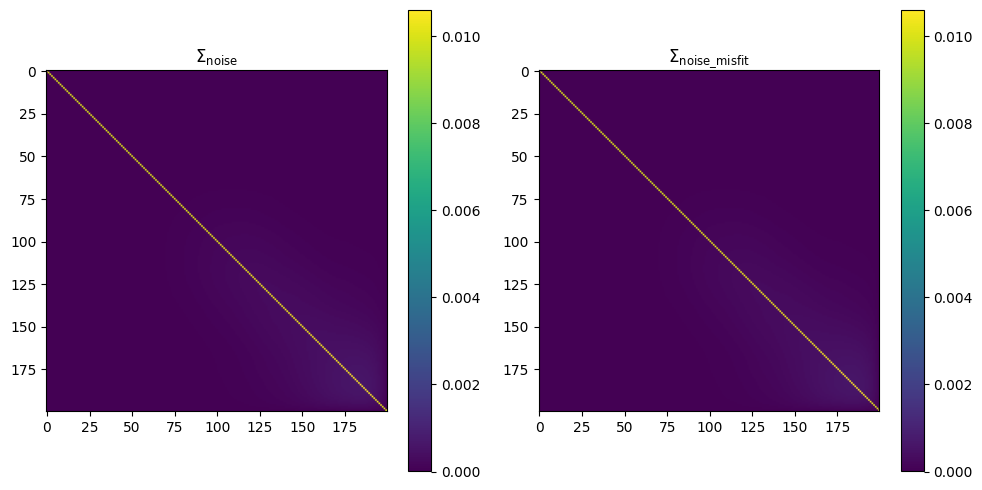

In [195]:

plot_matrices([Sigma_noise, Sigma_noise_misfit], [r"$\Sigma_{\rm noise}$",r"$\Sigma_{\rm noise\_misfit}$"], figsize=(10, 5))

### 8c. Signal covariance $\Sigma_{\rm signal}$

$$
\Sigma_{\rm signal} = \Sigma_{\rm obs}
+ l_\theta^\top
  \left(\Sigma_\theta^{-1} + \mathcal{H}_\theta^{\Sigma_{\rm obs}}\right)^{-1}
  l_\theta
$$

In [196]:
def compute_Sigma_signal(l_theta_eta, H_theta_eta, Sigma_theta_eta, Sigma_obs):
    """Compute the signal covariance matrix.

    Parameters
    ----------
    l_theta_eta    : ndarray (d, m)  — l_theta(u) or l_{(theta,eta)}(u)
    H_theta_eta    : ndarray (d, d)  — H_theta^{Sigma_obs} (or full block)
    Sigma_theta_eta: ndarray (d, d)  — prior covariance (or full joint covariance)
    Sigma_obs  : ndarray (m, m)

    Returns
    -------
    Sigma_signal : ndarray (m, m)
    """
    N = Sigma_theta_eta.shape[0]
    # Woodbury: (Sigma^{-1} + H)^{-1} = Sigma - Sigma(I + H Sigma)^{-1} H Sigma
    HS = H_theta_eta @ Sigma_theta_eta
    M = Sigma_theta_eta - Sigma_theta_eta @ la.solve(np.eye(N) + HS, HS)
    return Sigma_obs + l_theta_eta.T @ M @ l_theta_eta


In [197]:
def compute_Sigma_signal_misfit(l_theta_eta, H_theta_eta, Sigma_theta_eta, Sigma_obs):
    """
    Compute the signal covariance matrix.

    Parameters
    ----------
    l_theta_eta     : ndarray (d, m)
    H_theta_eta     : ndarray (d, d)
    Sigma_theta_eta : ndarray (d, d)
    Sigma_obs   : ndarray (m, m)

    Returns
    -------
    Sigma_signal : ndarray (m, m)
    """

    # Symmetric square root of Sigma_theta
    eigvals, eigvects = np.linalg.eigh(Sigma_theta_eta)

    # Numerical safeguard
    eigvals = np.clip(eigvals, 0.0, None)

    Sigma_theta_eta_sqrt = (
        eigvects
        @ np.diag(np.sqrt(eigvals))
        @ eigvects.T
    )

    H_misfit = (
        Sigma_theta_eta_sqrt
        @ H_theta_eta
        @ Sigma_theta_eta_sqrt
    )

    I_plus_H_misfit = np.eye(H_misfit.shape[0]) + H_misfit

    A = (
        Sigma_theta_eta_sqrt
        @ la.solve(I_plus_H_misfit, Sigma_theta_eta_sqrt)
    )

    X = A @ l_theta_eta

    return Sigma_obs + l_theta_eta.T @ X

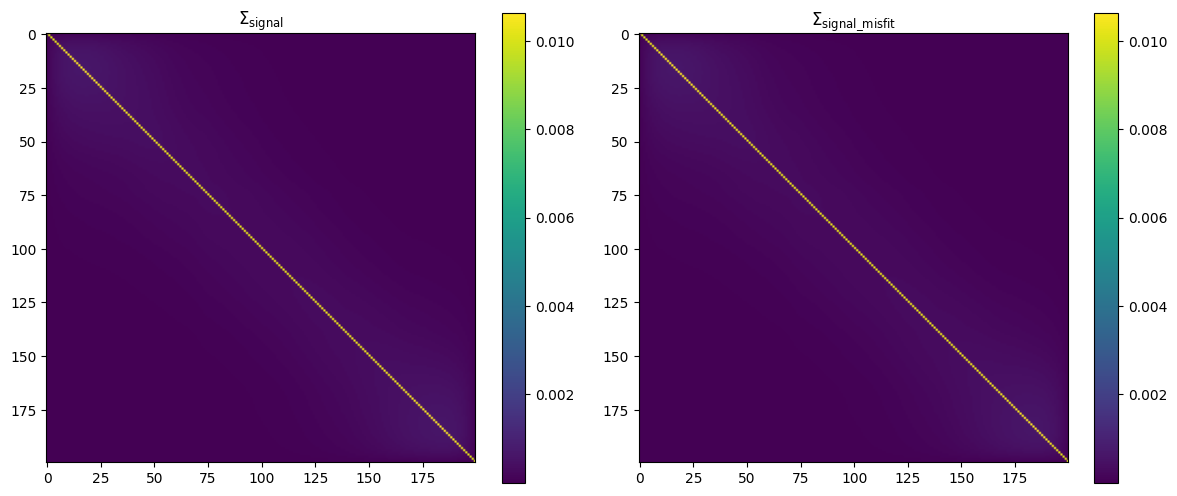

In [198]:
Sigma_signal = compute_Sigma_signal(
    l_theta_eta=res_l["EJ_full_T"],
    H_theta_eta=res_H["Cov_full"],
    Sigma_theta_eta=prior.Sigma,
    Sigma_obs=noise.get_covariance(N),
)

Sigma_signal_misfit = compute_Sigma_signal_misfit(
    l_theta_eta=res_l["EJ_full_T"],
    H_theta_eta=res_H["Cov_full"],
    Sigma_theta_eta=prior.Sigma,
    Sigma_obs=noise.get_covariance(N),
)

plot_matrices([Sigma_signal, Sigma_signal_misfit], [r"$\Sigma_{\rm signal}$", r"$\Sigma_{\rm signal\_misfit}$"], figsize=(12, 5))

### 8d. Conditional output covariance $\Sigma_{Y|\theta}$

$$
\Sigma_{Y|\theta} = \Sigma_{\rm obs}
+ \mathbb{E}_\theta\!\left[\mathrm{Cov}\bigl(G(\theta,\eta)\mid\theta\bigr)\right]
$$

In [199]:
def _process_theta(i, theta_i, mu_theta, Sigma_theta, mu_eta, Sigma_et, 
                   Sigma_eta_given_theta, G, n_eta, base_seed):
    """Traitement pour un theta_i donné."""
    # Créer un générateur indépendant
    rng = np.random.default_rng(base_seed + i)
    # Conditional mean of eta given theta_i
    mu_eta_given_theta_i = mu_eta + Sigma_et @ la.solve(Sigma_theta, theta_i - mu_theta)
    # Draw eta from conditional distribution
    eta_cond = rng.multivariate_normal(
        mean=mu_eta_given_theta_i,
        cov=Sigma_eta_given_theta,
        size=n_eta,
    )
    vals = np.array([G(theta_i, eta_cond[j]) for j in range(n_eta)])
    if vals.ndim == 1:
        vals = vals[:, None]
    cov_i = np.cov(vals, rowvar=False, ddof=1)
    return cov_i

def estimate_E_cov_Y_given_theta(
    G, joint_prior, Sigma_obs, n_theta, n_eta, rng=None, n_jobs=-1
):
    """Estimate E_theta[Cov(Y | theta)] = Sigma_obs + E_theta[Cov(G(theta,eta)|theta)].

    For each theta_i, eta is drawn from the CONDITIONAL distribution
    eta | theta_i ~ N(mu_eta|theta_i, Sigma_eta|theta)
    so that cross-covariances Sigma_theta_eta are properly accounted for.

    Parameters
    ----------
    G           : callable  G(theta, eta) -> ndarray (m,)
    joint_prior : dict with keys 'mu' (N,), 'Sigma' (N,N), 'd', 'q'
    Sigma_obs   : ndarray (m, m)
    n_theta     : int
    n_eta       : int  (>= 2)
    rng         : np.random.Generator or None
    n_jobs      : int  — number of parallel jobs for joblib (-1 = all CPUs)

    Returns
    -------
    E_cov_Y_given_theta : ndarray (m, m)
    """
    if rng is None:
        rng = np.random.default_rng()
    if n_eta < 2:
        raise ValueError("n_eta must be >= 2 to estimate a covariance.")

    d = joint_prior["d"]
    q = joint_prior["q"]
    mu    = joint_prior["mu"]
    Sigma = joint_prior["Sigma"]

    mu_theta    = mu[:d]
    mu_eta      = mu[d:]
    Sigma_theta = Sigma[:d, :d]
    Sigma_eta   = Sigma[d:, d:]
    Sigma_et    = Sigma[d:, :d]   # Sigma_{eta, theta}

    # Precompute quantities for conditional eta | theta
    Sigma_theta_inv_Sigma_te = la.solve(Sigma_theta, Sigma_et.T)  # (d, q)
    Sigma_eta_given_theta = Sigma_eta - Sigma_et @ Sigma_theta_inv_Sigma_te  # (q, q)
    # Symmetrise and add jitter for numerical safety
    Sigma_eta_given_theta = 0.5 * (Sigma_eta_given_theta + Sigma_eta_given_theta.T)
    Sigma_eta_given_theta += 1e-12 * np.eye(q)

    # Draw outer theta samples from marginal p(theta)
    theta_samples = rng.multivariate_normal(mean=mu_theta, cov=Sigma_theta, size=n_theta)

    # Choisir un seed de base pour reproductibilité (à partir du rng actuel)
    base_seed = rng.integers(0, 2**30)

    # Parallélisation
    inner_cov_list = Parallel(n_jobs=n_jobs)(
        delayed(_process_theta)(i, theta_samples[i], mu_theta, Sigma_theta,
                                mu_eta, Sigma_et, Sigma_eta_given_theta,
                                G, n_eta, base_seed)
        for i in range(n_theta)
    )

    result = Sigma_obs + np.mean(np.asarray(inner_cov_list), axis=0)
    return 0.5 * (result + result.T)

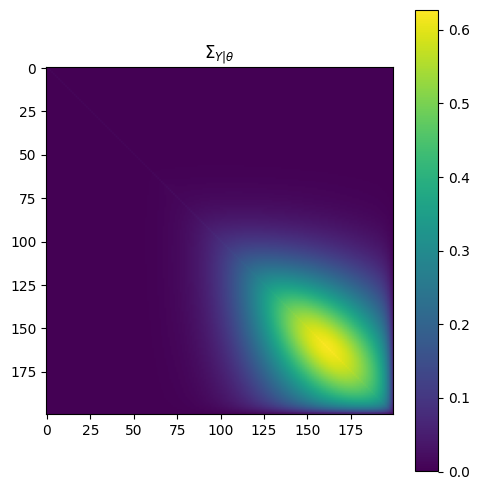

In [200]:
Sigma_Y_given_theta = estimate_E_cov_Y_given_theta(
    G=G, joint_prior=joint_prior,
    Sigma_obs=noise.get_covariance(N), n_theta=n_samples, n_eta=200,
)

plot_matrices([Sigma_Y_given_theta], [r"$\Sigma_{Y|\theta}$"], figsize=(5, 5))

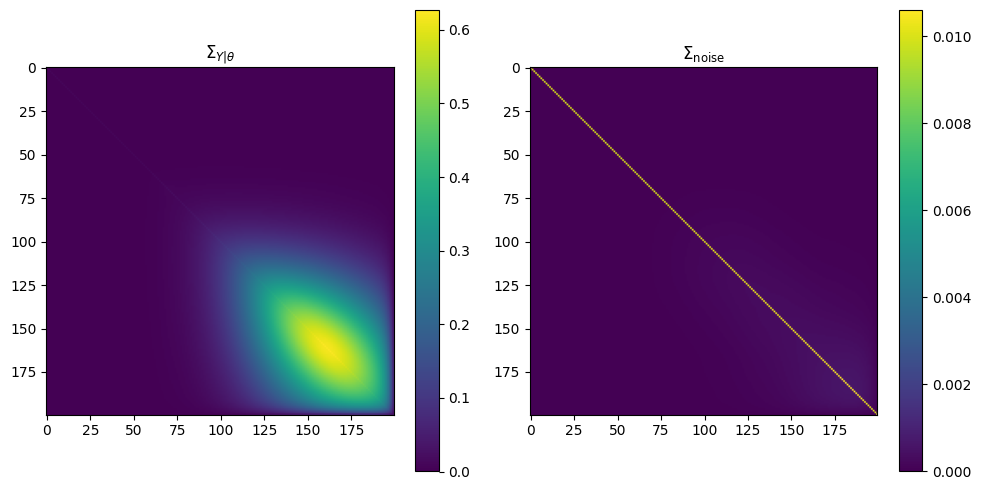

relative error 2 Sigma_Y|theta, Sigma_noise :        0.952377750945312
relative error fro Sigma_Y|theta, Sigma_noise :       0.9987615887180885


In [201]:
####
plot_matrices([Sigma_Y_given_theta,Sigma_noise], [r"$\Sigma_{Y|\theta}$",r"$\Sigma_{\rm noise}$"], figsize=(10, 5))
print(f"relative error 2 Sigma_Y|theta, Sigma_noise : \
       {np.linalg.norm(Sigma_Y_given_theta-Sigma_noise,ord='nuc')/np.linalg.norm(Sigma_Y_given_theta,ord='nuc')}")
print(f"relative error fro Sigma_Y|theta, Sigma_noise : \
      {np.linalg.norm(Sigma_Y_given_theta-Sigma_noise,ord='fro')/np.linalg.norm(Sigma_Y_given_theta,ord='fro')}")

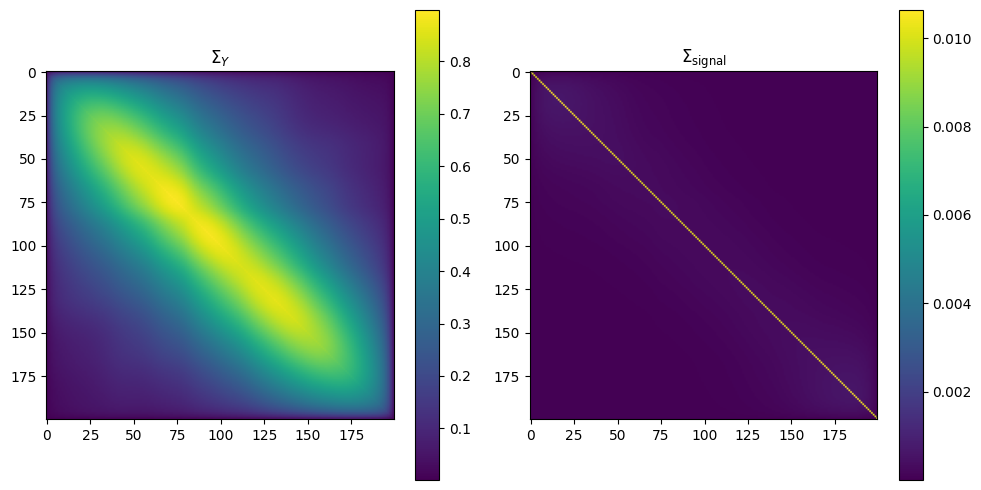

relative error 2 Sigma_Y, Sigma_signal : 0.9856473955921362
relative error fro Sigma_Y, Sigma_signal : 0.9994114771174613


In [202]:
plot_matrices([Sigma_Y,Sigma_signal], [r"$\Sigma_{Y}$",r"$\Sigma_{\rm signal}$"], figsize=(10, 5))
print(f"relative error 2 Sigma_Y, Sigma_signal : {np.linalg.norm(Sigma_Y-Sigma_signal,ord='nuc')/np.linalg.norm(Sigma_Y,ord='nuc')}")
print(f"relative error fro Sigma_Y, Sigma_signal : {np.linalg.norm(Sigma_Y-Sigma_signal,ord='fro')/np.linalg.norm(Sigma_Y,ord='fro')}")

## 9. Gradient-Free Based

### Noise covariance $\Sigma_{\rm noise}$

$$
\Sigma_{\mathrm{noise}}^{-1} \succeq \mathbb{E}\!\left[\mathcal{I}_{Y\mid\theta}\right]
$$
We have equality in the gaussian linear setting 
$$\mathbb{E}\left(\mathcal{I}_{Y|\theta} \right) = \Sigma_{\rm obs}^{-1} - 
\Sigma_{\rm obs}^{-1} \mathbb{E}\left[Cov\left(u(\theta,\eta)|\theta,Y\right)\right] \Sigma_{\rm obs}^{-1}$$

In [203]:
def solve_linear_regression_theta_Y(
    G,
    joint_prior,
    Sigma_obs,
    n_samples=10000,
    random_state=0,
    n_jobs=-1,
):
    """
    Linear regression of X on Z = (theta, Y):

        X = u(theta, eta)
        Y = X + eps

    We solve:
        min_{A,b} E ||X - A [theta; Y] - b||^2

    Parameters
    ----------
    G           : callable  G(theta, eta) -> ndarray (p,)
    joint_prior : dict with keys 'mu' (N,), 'Sigma' (N,N), 'd', 'q'
    Sigma_obs   : ndarray (p, p)
    n_samples   : int
    random_state: int or None
    n_jobs      : int  — number of parallel jobs for joblib (-1 = all CPUs)

    Returns
    -------
    A, b, M_emp, stats
    """
    rng = np.random.default_rng(random_state)

    # Génération des échantillons (theta, eta) depuis la prior jointe
    theta_samples, eta_samples = sample_joint_prior(
        joint_prior, n_samples, rng=rng
    )

    # Évaluation parallèle de G pour chaque (theta, eta)
    # On utilise Parallel sur la liste des indices
    X_list = Parallel(n_jobs=n_jobs)(
        delayed(G)(theta_samples[k], eta_samples[k]) for k in range(n_samples)
    )

    X = np.asarray(X_list, dtype=float)
    if X.ndim != 2:
        raise ValueError("G must return 1D arrays of fixed dimension p.")
    n, p = X.shape

    Sigma_obs = np.asarray(Sigma_obs)
    eps = rng.multivariate_normal(
        np.zeros(p), Sigma_obs, size=n_samples
    )
    Y = X + eps

    # Construction de Z = (theta, Y)
    theta = np.asarray(theta_samples)
    if theta.ndim == 1:
        theta = theta[:, None]

    Z = np.hstack([theta, Y])

    # Centrage
    m_X = X.mean(axis=0)
    m_Z = Z.mean(axis=0)

    Xc = X - m_X
    Zc = Z - m_Z

    # Covariances
    Sigma_XZ = (Xc.T @ Zc) / n
    Sigma_ZZ = (Zc.T @ Zc) / n
    Sigma_X = (Xc.T @ Xc) / n

    # Résolution des moindres carrés
    A = Sigma_XZ @ np.linalg.pinv(Sigma_ZZ)
    b = m_X - A @ m_Z

    # Résidus
    R = X - (Z @ A.T + b)
    M_emp = (R.T @ R) / n

    M_trace = np.trace(M_emp)   # pour info

    stats = {
        "m_X": m_X,
        "m_Z": m_Z,
        "Sigma_XZ": Sigma_XZ,
        "Sigma_ZZ": Sigma_ZZ,
        "Sigma_X": Sigma_X,
        "X": X,
        "Y": Y,
        "Z": Z,
        "residuals": R,
        "trace_empirical": M_trace,
    }

    return A, b, M_emp, stats

In [204]:
A_star, b_star, M_emp, stats = solve_linear_regression_theta_Y(
    G = G,
    joint_prior = joint_prior,
    Sigma_obs = noise.get_covariance(N),
    n_samples=20000,
    random_state=0,
)
print(M_emp.shape)

(200, 200)


In [205]:
Sigma_obs = noise.get_covariance(N)
Sobs_inv = np.linalg.inv(Sigma_obs)
EIytheta = Sobs_inv @ (np.eye(N) - M_emp @ Sobs_inv)
Sigma_noise_free = np.linalg.inv(EIytheta)

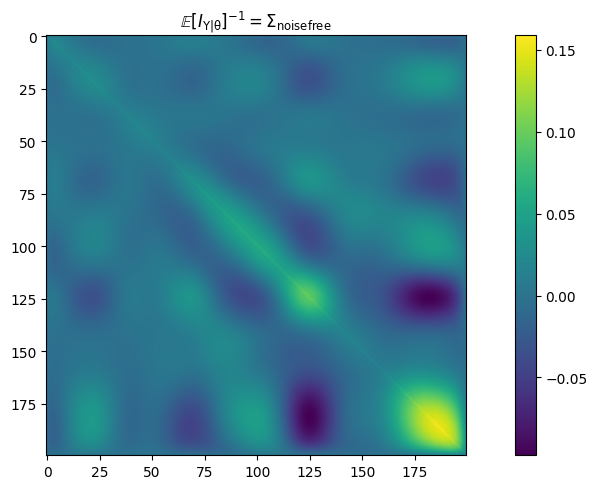

In [206]:
plot_matrices([Sigma_noise_free], [r"$\mathbb{E}\left[I_{\rm Y|\theta}\right]^{-1} = \Sigma_{\rm noise free}$"], figsize=(10, 5))


### Signal covariance $\Sigma_{\rm signal}$

$$
\Sigma_{\mathrm{signal}}^{-1} \succeq \mathcal{I}_Y
$$

We have equality in the gaussian linear setting 

$$\mathcal{I}_Y = \Sigma_{\rm obs}^{-1} - \Sigma_{\rm obs}^{-1} \mathbb{E}\left[Cov\left(u(\theta,\eta)|Y\right)\right] \Sigma_{\rm obs}^{-1}$$

In [207]:
def solve_linear_matrix_regression_minimization(
    G,
    joint_prior,
    Sigma_obs,
    n_samples=10000,
    random_state=0,
):
    """
    Solve the affine matrix-valued regression problem

        min_{A,b} E[(X - A Y - b)(X - A Y - b)^T],

    where
        theta ~ N(m_theta, Sigma_theta),
        X = u(theta,eta),
        Y = X + eps,
        eps ~ N(0, Sigma_obs), independent.

    Returns
    -------
    A_star : ndarray, shape (p, p)
        Optimal linear matrix.
    b_star : ndarray, shape (p,)
        Optimal intercept.
    M_emp : ndarray, shape (p, p)
        Empirical residual matrix:
            E[(X - A*Y - b*)(X - A*Y - b*)^T]
    M_formula : ndarray, shape (p, p)
        Same quantity computed from covariance formula:
            Sigma_X - Sigma_X (Sigma_X + Sigma_obs)^(-1) Sigma_X
    stats : dict
        Extra moments and samples.
    """

    Sigma_obs = np.asarray(Sigma_obs)
    rng = np.random.default_rng()
    # d = m_theta.shape[0]
    theta_samples, eta_samples = sample_joint_prior(joint_prior, n_samples, rng=rng)

    X_list = Parallel(n_jobs=-1)(
        delayed(G)(theta_samples[k],eta_samples[k]) for k in range(n_samples))
    X = np.asarray(X_list, dtype=float)
    if X.ndim != 2:
        raise ValueError("u(theta) must return a 1D array with fixed length p.")

    n, p = X.shape
    if Sigma_obs.shape != (p, p):
        raise ValueError(f"Sigma_obs must have shape ({p}, {p}).")

    eps = rng.multivariate_normal(np.zeros(p), Sigma_obs, size=n_samples)
    Y = X + eps

    m_X = X.mean(axis=0)
    m_Y = Y.mean(axis=0)

    Xc = X - m_X
    Yc = Y - m_Y

    # Empirical covariances
    Sigma_XY = (Xc.T @ Yc) / n
    Sigma_YY = (Yc.T @ Yc) / n
    Sigma_X = (Xc.T @ Xc) / n

    # Optimal affine predictor X ≈ A Y + b
    A_star = Sigma_XY @ np.linalg.inv(Sigma_YY)
    b_star = m_X - A_star @ m_Y

    # Residual matrix at optimum
    R = X - (Y @ A_star.T + b_star)
    M_emp = (R.T @ R) / n

    # Closed-form matrix for this minimization problem
    M_formula = Sigma_X - Sigma_X @ np.linalg.inv(Sigma_X + Sigma_obs) @ Sigma_X

    stats = {
        "m_X": m_X,
        "m_Y": m_Y,
        "Sigma_X": Sigma_X,
        "Sigma_XY": Sigma_XY,
        "Sigma_YY": Sigma_YY,
        "X": X,
        "Y": Y,
        "residuals": R,
    }

    return A_star, b_star, M_emp, M_formula, stats

In [208]:
A_star, b_star, M_emp, M_formula, stats = solve_linear_matrix_regression_minimization(
    G = G,
    joint_prior = joint_prior,
    Sigma_obs = noise.get_covariance(N),
    n_samples=20000,
    random_state=0,
)
print(M_emp.shape)

(200, 200)


In [209]:
print(f"relative error nuc in %: {np.round(np.linalg.norm(M_emp-M_formula,ord='nuc')*100/np.linalg.norm(M_formula,ord='nuc'),2)} %")
print(f"relative error fro in %: {np.round(np.linalg.norm(M_emp-M_formula,ord='nuc')*100/np.linalg.norm(M_formula,ord='fro'),2)} %")

relative error nuc in %: 3.25 %
relative error fro in %: 15.63 %


In [210]:
Sigma_obs = noise.get_covariance(N)
Sobs_inv = np.linalg.inv(Sigma_obs)
Iy = Sobs_inv @ (np.eye(N) - M_formula @ Sobs_inv)
Sigma_signal_free = np.linalg.inv(Iy)

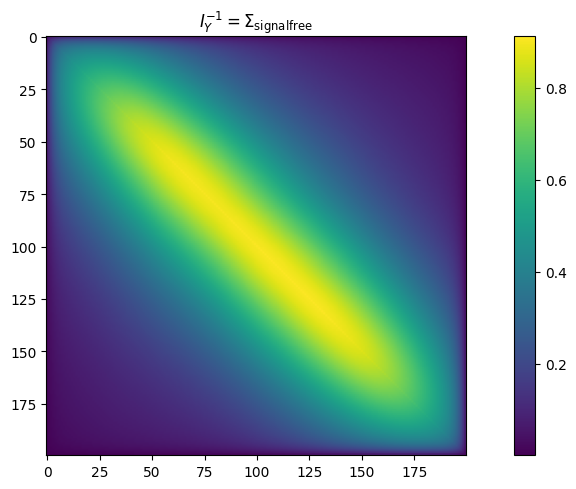

In [211]:
plot_matrices([Sigma_signal_free], [r"$I_Y^{-1} = \Sigma_{\rm signal free}$"], figsize=(10, 5))

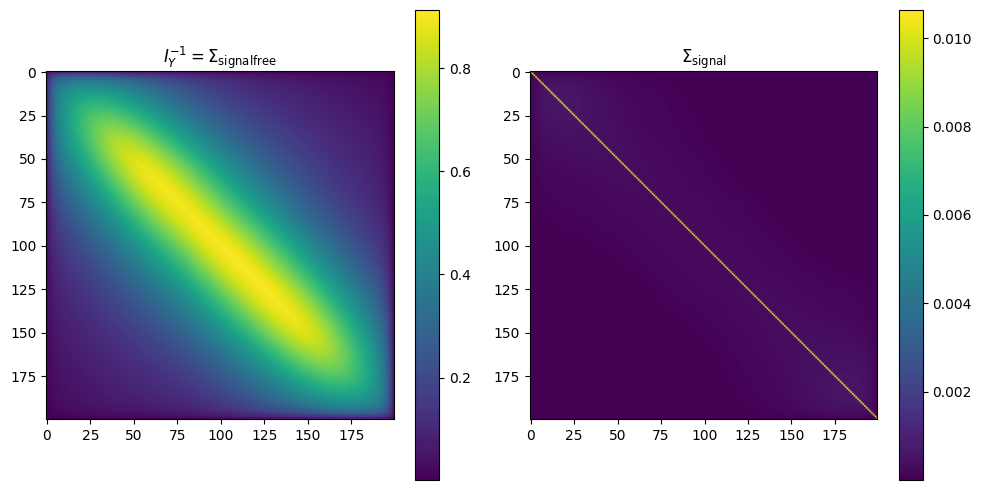

In [212]:
plot_matrices([Sigma_signal_free, Sigma_signal], [r"$I_Y^{-1} = \Sigma_{\rm signal free}$",r"$\Sigma_{\rm signal}$"], figsize=(10, 5))

In [213]:
print(f"relative error nuc in %: {np.round(np.linalg.norm(Sigma_signal-Sigma_Y,ord='nuc')*100/np.linalg.norm(Sigma_Y,ord='nuc'),2)} %")
print(f"relative error fro in %: {np.round(np.linalg.norm(Sigma_signal_free-Sigma_Y,ord='fro')*100/np.linalg.norm(Sigma_Y,ord='nuc'),2)} %")

relative error nuc in %: 98.56 %
relative error fro in %: 3.21 %


## 10. EIG Estimators

For a sensor-selection matrix $W \in \mathbb{R}^{N\times s}$, we define the
**relative** EIG gain (over the full-observation design $I$):

$$
\Delta\mathrm{EIG}(W) = \mathrm{EIG}(W) - \mathrm{EIG}(I)
= \frac{1}{2}\log\frac{\det(W^\top A\, W)}{\det(W^\top B\, W)}
  - \frac{1}{2}\log\frac{\det(A)}{\det(B)}
$$

where $(A,B)$ is $(\Sigma_{\rm signal}, \Sigma_{\rm Y|\theta})$ for the **upper bound (LB)**
and $(\Sigma_Y, \Sigma_{\rm noise})$ for the **direct estimator (BI)**.

### 10a. Upper bound (UB) — based on $\Sigma_{\rm signal}$ and $\Sigma_{\rm Y|\theta}$

In [214]:
def eig_UB(Sigma_signal, Sigma_Y_given_theta, W):
    """EIG upper bound (UB) relative to the full-observation design.

    Parameters
    ----------
    Sigma_signal         : ndarray (m, m)
    Sigma_Y_given_theta  : ndarray (m, m)
    W                    : ndarray (m, s)  — sensor selection matrix

    Returns
    -------
    float  — Delta EIG_UB(W)
    """
    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_Y_given_theta.shape[0])
    return 0.5 * (log_ratio(Sigma_signal, Sigma_Y_given_theta, W)
                  - log_ratio(Sigma_signal, Sigma_Y_given_theta, eye))

### 10b. Direct estimator (BI) — based on $\Sigma_Y$ and $\Sigma_{\rm noise}$

In [215]:
def eig_LB(Sigma_Y, Sigma_noise, W):
    """EIG direct estimator (LB) relative to the full-observation design.

    Parameters
    ----------
    Sigma_Y      : ndarray (m, m)
    Sigma_noise  : ndarray (m, m)
    W            : ndarray (m, s)  — sensor selection matrix

    Returns
    -------
    float  — Delta EIG_LB(W)
    """
    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_noise.shape[0])
    return 0.5 * (log_ratio(Sigma_Y, Sigma_noise, W)
                  - log_ratio(Sigma_Y, Sigma_noise, eye))

#### **Estimate EIG**

### Memory efficient EIG

In [216]:
from scipy.stats import qmc, norm
from joblib import Parallel, delayed
#import scipy.linalg as la
import numpy as np

def logsumexp_rows(A):
    amax = A.max(axis=1, keepdims=True)
    return amax.squeeze() + np.log(np.exp(A - amax).sum(axis=1))

def estimate_eig_memory_efficient(G, joint_prior, Sigma_obs, n_samples, batch_size=500):
    if n_samples < 2:
        raise ValueError("n_samples doit être >= 2")
    
    # 1. Échantillons theta selon Halton
    rng = np.random.default_rng()
    # d = m_theta.shape[0]
    theta_samples, eta_samples = sample_joint_prior(joint_prior, n_samples, rng=rng)
    
    # 2. Évaluations du modèle G (parallèle ou séquentiel)
    U = Parallel(n_jobs=-1)(
        delayed(G)(theta_samples[k], eta_samples[k]) for k in range(n_samples))
    U = np.array(U)
    
    m = U.shape[1]
    
    # 3. Constantes de vraisemblance
    Sinv = la.inv(Sigma_obs)
    _, ldet = la.slogdet(Sigma_obs)
    log_const = -0.5 * (ldet + m * np.log(2 * np.pi))
    
    # 4. Génération des observations bruitées Y (apariées : Y_i = G(theta_i) + epsilon_i)
    noise_mat = np.random.multivariate_normal(np.zeros(m), Sigma_obs, size=n_samples)
    Y = U + noise_mat
    
    # 5. Précalculs pour la forme quadratique décomposée
    Y_M = Y @ Sinv
    U_M = U @ Sinv
    normY = np.einsum('ij,ij->i', Y, Y_M)   # (n,)
    normU = np.einsum('ij,ij->i', U, U_M)   # (n,)
    
    # 6. Boucle par batch sur i pour éviter de stocker cross complet (n x n)
    eig_estimate = 0.0
    for i in range(0, n_samples, batch_size):
        i_end = min(i + batch_size, n_samples)
        batch_size_i = i_end - i
        
        cross_batch = Y_M[i:i_end, :] @ U.T          # (batch, n)
        normY_batch = normY[i:i_end]                 # (batch,)
        
        quad_batch = normY_batch[:, None] + normU[None, :] - 2 * cross_batch   # (batch, n)
        log_liks_batch = log_const - 0.5 * quad_batch
        
        log_num_batch = log_liks_batch[np.arange(batch_size_i), i + np.arange(batch_size_i)]
        log_den_batch = logsumexp_rows(log_liks_batch) - np.log(n_samples)
        eig_estimate += (log_num_batch - log_den_batch).sum()
    
    return eig_estimate / n_samples

### EIG via KLPrior (version GO)

Même principe que dans le cas standard : on applique la décomposition KL au **prior joint**
$z = (\theta, \eta) \sim \mathcal{N}(\mu, \Sigma)$ pour obtenir $z \approx \mu + V_k \,\mathrm{diag}(\sqrt{\lambda_k})\, \xi$, $\xi \sim \mathcal{N}(0, I_k)$.

On définit ensuite :
$$G_r(\xi) = G\!\bigl(z_{\rm KL}(\xi)_{:d},\; z_{\rm KL}(\xi)_{d:}\bigr), \qquad
J_r(\xi) = J^{\rm full}\!\bigl(z_{\rm KL}(\xi)\bigr)\, V_k \,\mathrm{diag}(\sqrt{\lambda_k})$$
et on applique directement `estimate_eig_kl` dans l'espace réduit.

In [217]:
class KLPrior:
    """
    Prior joint z = (theta, eta) ~ N(mu, Sigma) -> représentation KL tronquée.
    z = mu + V_k @ diag(sqrt(lam_k)) @ xi,   xi ~ N(0, I_k)
    """
    def __init__(self, mu, Sigma, energy=0.99999):
        self.mu_full = np.asarray(mu)
        ev, V = np.linalg.eigh(np.asarray(Sigma))
        ev    = ev[::-1];  V = V[:, ::-1]          # ordre décroissant
        cumvar = np.cumsum(ev) / ev.sum()
        self.k = int(np.searchsorted(cumvar, energy)) + 1
        self.V_k      = V[:, :self.k]              # (N, k)
        self.lam_k    = ev[:self.k]                # (k,)
        self.sqrt_lam = np.sqrt(self.lam_k)        # (k,)
        # prior dans l'espace réduit : xi ~ N(0, I_k)
        self.mu    = np.zeros(self.k)
        self.Sigma = np.eye(self.k)
        self.L     = np.eye(self.k)
        self.Sinv  = np.eye(self.k)
        captured = cumvar[self.k-1] * 100
        print(f"KL tronquée : {self.k} modes, {captured:.3f}% variance")

    def xi_to_z(self, xi):
        """xi (k,) -> z (N,)  (= (theta, eta) concatenés)"""
        return self.mu_full + self.V_k @ (self.sqrt_lam * xi)

    def make_G_reduced(self, G_joint):
        """G_r(xi) = G_joint( xi_to_z(xi) )"""
        return lambda xi: G_joint(self.xi_to_z(xi))

    def make_J_reduced(self, J_G_joint):
        """J_r(xi) = J_G_joint( xi_to_z(xi) ) @ V_k @ diag(sqrt_lam)"""
        def J_reduced(xi):
            z = self.xi_to_z(xi)
            J = np.asarray(J_G_joint(z))                          # (m, N)
            return J @ self.V_k @ np.diag(self.sqrt_lam)         # (m, k)
        return J_reduced

kl_prior_joint = KLPrior(prior.mu, prior.Sigma)

KL tronquée : 95 modes, 99.999% variance


In [218]:
# Wrappers qui présentent G et son jacobien complet via un vecteur joint z = (theta, eta)
def G_joint(z):
    """G(theta, eta) vu comme une fonction de z = concat(theta, eta)."""
    return G(z[:d], z[d:])

def J_G_joint(z):
    """Jacobien complet [J_theta | J_eta] en fonction de z."""
    return jacobian_fd_full(G, z[:d], z[d:])

In [219]:
def estimate_eig_kl(G_j, J_G_j, kl_prior, Sigma_obs, n_outer, seed=None, n_jobs=-1):
    """
    Estimateur KL de l'EIG pour le cas GO.
    Travaille dans l'espace réduit xi ~ N(0, I_k) issu de la décomposition KL du prior joint.
    """
    G_r  = kl_prior.make_G_reduced(G_j)
    J_r  = kl_prior.make_J_reduced(J_G_j)
    k    = kl_prior.k
    m    = len(Sigma_obs)

    L_obs    = sla.cholesky(Sigma_obs, lower=True)
    Sinv_obs = sla.cho_solve((L_obs, True), np.eye(m))
    _, ld    = la.slogdet(Sigma_obs)
    log_c    = -0.5 * (ld + m * np.log(2 * np.pi))

    ss    = np.random.SeedSequence(seed)
    seeds = ss.spawn(n_outer)

    def _step(seed_i):
        rng = np.random.default_rng(seed_i)

        xi = rng.standard_normal(k)
        Gr = np.asarray(G_r(xi))
        Jr = np.asarray(J_r(xi))                   # (m, k)

        # Marginale linéarisée S = J_r J_r^T + Sigma_obs
        S       = Jr @ Jr.T + Sigma_obs
        L_S     = sla.cholesky(S, lower=True)
        Sinv_S  = sla.cho_solve((L_S, True), np.eye(m))
        _, ld_S = la.slogdet(S)
        log_c_S = -0.5 * (ld_S + m * np.log(2 * np.pi))

        bias_corr = 0.5 * (np.trace(Sinv_S @ Sigma_obs) - m)

        eps = rng.multivariate_normal(np.zeros(m), Sigma_obs)
        y   = Gr + eps

        log_lik = log_c - 0.5 * np.dot(eps, Sinv_obs @ eps)

        r      = y - Gr
        log_py = log_c_S - 0.5 * r @ Sinv_S @ r

        return float(log_lik - log_py - bias_corr)

    results = Parallel(n_jobs=n_jobs)(
        delayed(_step)(seeds[i]) for i in range(n_outer)
    )
    return float(np.mean(results))

In [220]:
# KL prior pour theta seulement (eta marginalisé comme nuisance)
kl_prior_theta = KLPrior(theta_prior['mu'], theta_prior['Sigma'])

# E[eta | theta] = A_cond @ (theta - mu_theta),  A_cond = Sigma_eta_theta @ inv(Sigma_theta)
A_cond = np.linalg.solve(theta_prior['Sigma'], Sigma_eta_theta.T).T  # (q, d)

def G_eff(theta):
    eta_cond = A_cond @ (theta - theta_prior['mu'])
    return G(theta, eta_cond)

def J_G_eff(theta):
    eta_cond = A_cond @ (theta - theta_prior['mu'])
    J_th = jacobian_fd_theta(G, theta, eta_cond)  # (m, d)
    J_et = jacobian_fd_eta(G, theta, eta_cond)    # (m, q)
    return J_th + J_et @ A_cond                   # (m, d)

eig_kl = estimate_eig_kl(
    G_eff, J_G_eff, kl_prior_theta,
    Sigma_Y_given_theta, n_outer=1000, seed=42, n_jobs=-1
)
print(f"EIG theta (KL, nuisance marginalise) : {eig_kl:.4f}")


KL tronquée : 48 modes, 99.999% variance


EIG theta (KL, nuisance marginalise) : 10.3734


## 11. Greedy Sensor Placement and Comparison

We greedily maximise the BI lower bound to select a budget of sensors,
then evaluate both estimators on the resulting design.

In [221]:
def greedy_maximize_LB(Sigma_Y, Sigma_noise, n_sensors):
    """Greedy forward selection maximising the BI log-ratio score.

    Parameters
    ----------
    Sigma_Y     : ndarray (N, N)
    Sigma_noise : ndarray (N, N)
    n_sensors   : int

    Returns
    -------
    selected : ndarray of int, shape (n_sensors,)
    """
    N_grid = Sigma_Y.shape[0]
    selected = []
    remaining = list(range(N_grid))

    for _ in range(n_sensors):
        best_idx, best_score = None, -np.inf
        for idx in remaining:
            S  = selected + [idx]
            ix = np.ix_(S, S)
            sign_y, logdet_y = np.linalg.slogdet(Sigma_Y[ix])
            sign_n, logdet_n = np.linalg.slogdet(Sigma_noise[ix])
            if sign_y <= 0 or sign_n <= 0:
                raise ValueError(f"Sub-matrix is not SPD for S={S}")
            score = 0.5 * (logdet_y - logdet_n)
            if score > best_score:
                best_score = score
                best_idx   = idx
        selected.append(best_idx)
        remaining.remove(best_idx)

    return np.array(selected, dtype=int)

##  12. Incremental bounds

In [222]:
def schur(Sigma: np.ndarray, Wm: np.ndarray) -> np.ndarray:
    """Complément de Schur conditionnel.

    Calcule Σ(Wm) = Σ - Σ Wm (WmᵀΣWm)⁻¹ Wmᵀ Σ,
    c'est-à-dire la covariance de Σ conditionnée sur les directions Wm.

    Utilise une factorisation de Cholesky pour garantir que le résultat
    reste symétrique défini positif numériquement.

    Parameters
    ----------
    Sigma : (N, N) ndarray, symétrique définie positive.
    Wm    : (N, m) ndarray. Si m=0 (matrice vide), retourne Sigma inchangé.

    Returns
    -------
    (N, N) ndarray : Σ(Wm), symétrique définie positive.
    """
    if Wm.size == 0:
        return Sigma
    G = Wm.T @ Sigma @ Wm          # (m, m)  SDP
    L = np.linalg.cholesky(G)      # G = LLᵀ
    B = np.linalg.solve(L, Wm.T @ Sigma)   # (m, N)  B = L⁻¹ WᵀΣ
    return Sigma - B.T @ B         # Σ - BᵀB  symétrique par construction


def incremental_bounds(
    Sigma_signal:        np.ndarray,
    Sigma_Y_given_theta: np.ndarray,
    Sigma_Y:             np.ndarray,
    Sigma_noise:         np.ndarray,
    n_sensors:           int,
) -> dict:
    """Placement glouton de capteurs par bornes incrémentales sur l'EIG.

    Implémente le théorème suivant : pour W_new = eᵢ,

        EIG(Wm ∪ {i}) ≥ EIG(Wm) + ½ log [Σ_signal(Wm)]ᵢᵢ / [Σ_{Y|θ}(Wm)]ᵢᵢ   (borne inf)
        EIG(Wm ∪ {i}) ≤ EIG(Wm) + ½ log [Σ_Y(Wm)]ᵢᵢ     / [Σ_noise(Wm)]ᵢᵢ    (borne sup)

    où Σ_*(Wm) désigne le complément de Schur de Σ_* conditionné sur Wm
    (cf. équations (11)–(14) du théorème de référence).

    La sélection gloutonne maximise la borne inférieure à chaque étape.
    La borne supérieure accumulée correspond à la même séquence de capteurs
    (elle n'est pas nécessairement la borne sup glouton-optimale).

    Parameters
    ----------
    Sigma_signal        : (N, N)  Covariance a priori du paramètre θ.  Éq. (11).
    Sigma_Y_given_theta : (N, N)  Covariance de Y|θ (bruit d'observation).  Éq. (13).
                          ⚠ Ne pas confondre avec Σ_{θ|Y} (posterior sur θ).
    Sigma_Y             : (N, N)  Covariance marginale de Y.  Éq. (14).
    Sigma_noise         : (N, N)  Covariance du bruit capteur.  Éq. (12).
    n_sensors           : int     Nombre de capteurs à sélectionner.

    Returns
    -------
    dict avec les clés :
        "indices"          : (n_sensors,) int    — indices sélectionnés dans l'ordre.
        "increments_lower" : list[float]         — δ⁻(i*_m, m) à chaque étape.
        "increments_upper" : list[float]         — δ⁺(i*_m, m) à chaque étape.
        "EIG_lower_bound"  : float               — borne inf cumulée sur EIG(S_n).
        "EIG_upper_bound"  : float               — borne sup cumulée sur EIG(S_n).
    """
    N = Sigma_Y.shape[0]
    assert Sigma_signal.shape        == (N, N), "Sigma_signal: dimension incorrecte"
    assert Sigma_Y_given_theta.shape == (N, N), "Sigma_Y_given_theta: dimension incorrecte"
    assert Sigma_noise.shape         == (N, N), "Sigma_noise: dimension incorrecte"
    assert 1 <= n_sensors <= N,                 "n_sensors hors borne"

    # Copies de travail pour les mises à jour de Schur incrémentales.
    # À l'étape m, S_*[i,i] = [Σ_*(W_m)]ᵢᵢ sans recalcul depuis zéro.
    S_s   = Sigma_signal.copy()
    S_yth = Sigma_Y_given_theta.copy()
    S_Y   = Sigma_Y.copy()
    S_n   = Sigma_noise.copy()

    selected:  list[int]   = []
    remaining: list[int]   = list(range(N))
    inc_inf:   list[float] = []
    inc_sup:   list[float] = []
    eig_inf = eig_sup = 0.0

    for _ in range(n_sensors):
        best_idx  = None
        best_dinf = -np.inf
        best_dsup = None

        for idx in remaining:
            num_inf = S_s[idx, idx]
            den_inf = S_yth[idx, idx]
            num_sup = S_Y[idx, idx]
            den_sup = S_n[idx, idx]

            # Les variances conditionnelles doivent être > 0 (SDP).
            # Une valeur nulle ou négative signale une dégénérescence numérique.
            if min(num_inf, den_inf, num_sup, den_sup) <= 1e-14:
                warnings.warn(
                    f"Variance conditionnelle quasi-nulle pour le capteur {idx} "
                    f"(num_inf={num_inf:.2e}, den_inf={den_inf:.2e}, "
                    f"num_sup={num_sup:.2e}, den_sup={den_sup:.2e}). "
                    "Capteur ignoré — vérifier le conditionnement des matrices.",
                    RuntimeWarning,
                    stacklevel=2,
                )
                continue

            d_inf = 0.5 * np.log(num_inf / den_inf)
            d_sup = 0.5 * np.log(num_sup / den_sup)

            if d_inf > best_dinf:
                best_dinf = d_inf
                best_dsup = d_sup
                best_idx  = idx

        if best_idx is None:
            warnings.warn(
                f"Aucun capteur valide à l'étape {len(selected)+1}/{n_sensors}. "
                "Arrêt prématuré.",
                RuntimeWarning,
                stacklevel=2,
            )
            break

        # Mise à jour incrémentale de Schur par rang 1 :
        #   Σ_*(W_{m+1}) = Σ_*(W_m) - [Σ_*(W_m) eᵢ eᵢᵀ Σ_*(W_m)] / [Σ_*(W_m)]ᵢᵢ
        # Complexité O(N²) par étape au lieu de O(N³).
        for S in (S_s, S_yth, S_Y, S_n):
            col = S[:, best_idx].copy()          # Σ eᵢ
            S -= np.outer(col, col) / S[best_idx, best_idx]

        selected.append(best_idx)
        remaining.remove(best_idx)
        eig_inf += best_dinf
        eig_sup += best_dsup
        inc_inf.append(best_dinf)
        inc_sup.append(best_dsup)

    return {
        "indices":          np.array(selected, dtype=int),
        "increments_lower": inc_inf,
        "increments_upper": inc_sup,
        "EIG_lower_bound":  eig_inf,
        "EIG_upper_bound":  eig_sup,
    }

In [223]:
def incremental_bounds_given_W(
    Sigma_signal:  np.ndarray,
    Sigma_Y_given_theta: np.ndarray,
    Sigma_Y:       np.ndarray,
    Sigma_noise:   np.ndarray,
    W:             np.ndarray
) -> tuple[float, float]:

    n_sensors = W.shape[1]

    lb = 0.0
    ub = 0.0
    _, logdet_sig = np.linalg.slogdet(W.T @ Sigma_signal  @ W)
    _, logdet_th  = np.linalg.slogdet(W.T @ Sigma_Y_given_theta @ W)
    lb += 0.5 * (logdet_sig - logdet_th)

    _, logdet_Y   = np.linalg.slogdet(W.T @ Sigma_Y     @ W)
    _, logdet_n   = np.linalg.slogdet(W.T @ Sigma_noise @ W)
    ub += 0.5 * (logdet_Y - logdet_n)

    return lb, ub

#### Greedy sensor placement : Maximizing Conservative lower bound

In [224]:
sensor_budgets = [5, 10,15,20,25]
lb_vals = []
ub_vals = []

lb_vals_inc = []
ub_vals_inc = []
Sigma_obs = noise.get_covariance(N)

for budget in sensor_budgets:
    indices = greedy_maximize_LB(
        Sigma_Y=Sigma_Y,
        Sigma_noise=Sigma_noise_misfit,
        n_sensors=budget
    )
    W_opt, _ = build_selection_matrices(N, indices)

    lb = eig_LB(Sigma_Y, Sigma_noise_misfit, W_opt)
    ub = eig_UB(Sigma_signal_misfit, Sigma_Y_given_theta, W_opt)

    lb_inc, ub_inc = incremental_bounds_given_W(
        Sigma_signal  = Sigma_signal,
        Sigma_Y_given_theta = Sigma_Y_given_theta,
        Sigma_Y       = Sigma_Y,
        Sigma_noise   = Sigma_noise,
        W = W_opt,       
    )

    lb_vals.append(lb)
    ub_vals.append(ub)

    lb_vals_inc.append(lb_inc)
    ub_vals_inc.append(ub_inc)


[-15.28219789 -10.14116621  -7.45624839  -5.76656184  -4.3368769 ]
[25.33627875 23.13912241 21.75291487 20.58932372 19.78270923]
------------------------------------------------------------
[-4.970004036710814, -7.167160376196469, -8.553367917579482, -9.716959075768841, -10.52357356376421]
[9.563507006734604, 14.704538685127728, 17.38945650555055, 19.079143052554574, 20.50882799215543]


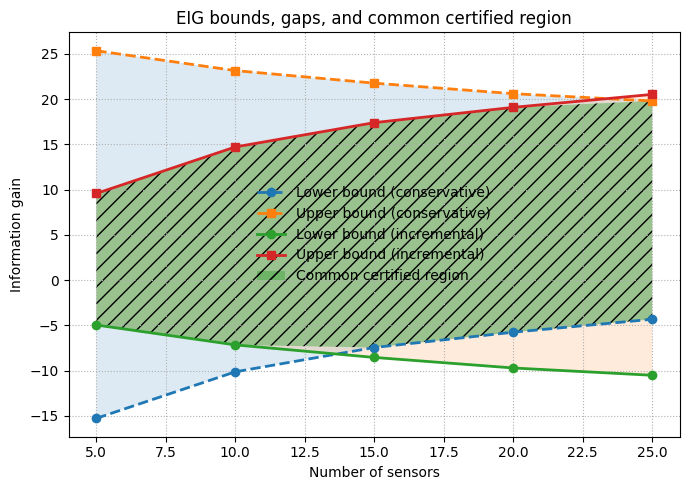

In [225]:


# ===============================
# Préparation des données
# ===============================

offset = eig_kl # mémoire spectrale

# Bornes conservatrices
lb_cons = np.array(lb_vals) + offset
ub_cons = np.array(ub_vals) + offset
print(lb_cons)
print(ub_cons)
print(60*"-")

# Bornes incrémentales
lb_inc = lb_vals_inc
ub_inc = ub_vals_inc
print(lb_inc)
print(ub_inc)

# Intersection des intervalles
lb_common = np.maximum(lb_cons, lb_inc)
ub_common = np.minimum(ub_cons, ub_inc)
mask = lb_common <= ub_common


# ===============================
# Figure
# ===============================

fig, ax = plt.subplots(figsize=(7, 5))

# --- Conservatif
ax.plot(sensor_budgets, lb_cons,
        '--o', linewidth=2,
        label='Lower bound (conservative)')
ax.plot(sensor_budgets, ub_cons,
        '--s', linewidth=2,
        label='Upper bound (conservative)')

ax.fill_between(sensor_budgets,
                lb_cons, ub_cons,
                alpha=0.15)

# --- Incrémental
ax.plot(sensor_budgets, lb_inc,
        '-o', linewidth=2,
        label='Lower bound (incremental)')
ax.plot(sensor_budgets, ub_inc,
        '-s', linewidth=2,
        label='Upper bound (incremental)')

ax.fill_between(sensor_budgets,
                lb_inc, ub_inc,
                alpha=0.15)

# --- Zone commune (mise en valeur)
ax.fill_between(sensor_budgets,
                lb_common, ub_common,
                where=mask,
                interpolate=True,
                alpha=0.4,
                hatch='//',
                label='Common certified region')

# ===============================
# Mise en forme
# ===============================

ax.set_xlabel("Number of sensors")
ax.set_ylabel("Information gain")
ax.set_title("EIG bounds, gaps, and common certified region")

ax.grid(True, which='both', linestyle=':', linewidth=0.8)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


#### Greedy sensor placememnt  : by getting incremental bounds

In [226]:
sensor_budgets = [5, 10,15,20,25]
lb_vals = []
ub_vals = []

lb_vals_inc = []
ub_vals_inc = []

Sigma_obs = noise.get_covariance(N)

for budget in sensor_budgets:
    result = incremental_bounds(
        Sigma_signal  = Sigma_signal_misfit,
        Sigma_Y_given_theta = Sigma_Y_given_theta,
        Sigma_Y       = Sigma_Y,
        Sigma_noise   = Sigma_noise_misfit,
        n_sensors     = budget,       
    )
    W_opt, _ = build_selection_matrices(N, result['indices'])

    lb = eig_LB(Sigma_Y, Sigma_noise_misfit, W_opt)
    ub = eig_UB(Sigma_signal_misfit, Sigma_Y_given_theta, W_opt)

    lb_vals.append(lb)
    ub_vals.append(ub)

    lb_vals_inc.append(result["EIG_lower_bound"])
    ub_vals_inc.append(result["EIG_upper_bound"])


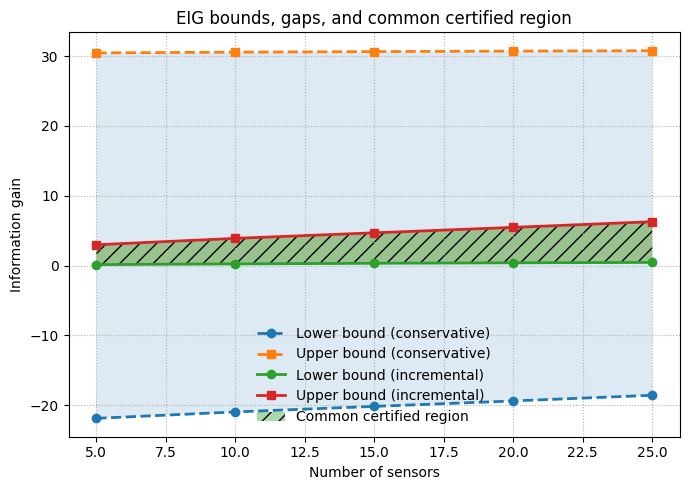

In [227]:
# ===============================
# Préparation des données
# ===============================


offset = eig_kl

# Bornes conservatrices
lb_cons = np.array(lb_vals) + offset
ub_cons = np.array(ub_vals) + offset

# Bornes incrémentales
lb_inc = np.array(lb_vals_inc)
ub_inc = np.array(ub_vals_inc)

# Intersection des intervalles
lb_common = np.maximum(lb_cons, lb_inc)
ub_common = np.minimum(ub_cons, ub_inc)
mask = lb_common <= ub_common


# ===============================
# Figure
# ===============================

fig, ax = plt.subplots(figsize=(7, 5))

# --- Conservatif
ax.plot(sensor_budgets, lb_cons,
        '--o', linewidth=2,
        label='Lower bound (conservative)')
ax.plot(sensor_budgets, ub_cons,
        '--s', linewidth=2,
        label='Upper bound (conservative)')

ax.fill_between(sensor_budgets,
                lb_cons, ub_cons,
                alpha=0.15)

# --- Incrémental
ax.plot(sensor_budgets, lb_inc,
        '-o', linewidth=2,
        label='Lower bound (incremental)')
ax.plot(sensor_budgets, ub_inc,
        '-s', linewidth=2,
        label='Upper bound (incremental)')

ax.fill_between(sensor_budgets,
                lb_inc, ub_inc,
                alpha=0.15)

# --- Zone commune
ax.fill_between(sensor_budgets,
                lb_common, ub_common,
                where=mask,
                interpolate=True,
                alpha=0.4,
                hatch='//',
                label='Common certified region')

# ===============================
# Mise en forme
# ===============================

ax.set_xlabel('Number of sensors')
ax.set_ylabel('Information gain')
ax.set_title('EIG bounds, gaps, and common certified region')

ax.grid(True, which='both', linestyle=':', linewidth=0.8)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()
